# P8. 피처 테이블 확정

기준 원고는 `reports/DS-MINI-Design-울산_4반-박연제.md`의 4장 정의서다. [설계 4장] [D34] [D41]

모델 입력은 `log10(var(ΔQ))`와 `qd_max_minus_2`뿐이다. 배제 피처의 계산 함수는 지우지 않고, 저장 표에는 넣지 않는다.


## 정의서와 배제

설계서 4장 최종 피처 정의서.

| 피처명 | 계산식 | 사용 데이터 | 전처리 | 예상 방향 | 근거 |
| --- | --- | --- | --- | --- | --- |
| log10(var(ΔQ)) | Qdlin[행 99] − Qdlin[행 9]의 1,000점 분산에 log10. ddof=1 | 사이클 100 − 10 | 없음 | 음(−) | [Q3] [Q5] [D09] |
| qd_max_minus_2 | 사이클 2~100 QD 최댓값 − 사이클 2 QD | summary QD, 사이클 2~100 | correct_summary_spikes | log10(var) 통제 후 음(−) | [Q5] [D10] |
| log10(cycle_life) | 학습 타깃. 예측 후 10의 거듭제곱으로 MAPE | cycle_life | 없음 | 타깃 | [Q1] [D11] |

설계서 4장 배제 표.

| 피처 | 이유 | 근거 |
| --- | --- | --- |
| log10(절댓값 min ΔQ) | var와 r=0.996, 잔차 상관 0.036, VIF 689·711 | [Q5] [D12] |
| ΔQ 2V 값, skew, kurtosis | 2V는 var와 r=−0.89. skew는 Batch 3에서 부호 반전 | [Q3] [Q5] [D13] |
| 초기 QD 기울기·절편, 사이클 2 QD | 절편과 사이클 2 QD는 r=0.999. 기울기 부호는 Batch 2에서 반전 | [Q2] [Q5] [D14] |
| knee | 수명의 78%(r=0.99). 검토 후 누수로 배제 | [Q2] [D15] |
| C1, 전환 SOC, C2, 평균 C-rate, 초기 chargetime | Batch 1 r=−0.53이 테스트에서 소멸 | [Q4] [D16] |
| 정규화 ΔQ, 배치 번호 | 깊이 비 1.30→1.29. 배치 효과는 Batch 1만으로 추정 불가 | [Q3] [Q5] [D17] |
| 온도 적분, IR | Q5에서 추가 신호가 아님 | [Q5] [D18] |


In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

from src.config import DATA_PROCESSED_DIR, FIGURES_DIR, set_korean_font
from src.features import (
    MODEL_FEATURES,
    build_feature_table,
    correct_summary_spikes,
    delta_q,
    delta_q_features,
    variance_inflation_factors,
)

set_korean_font()
print("모델 입력", MODEL_FEATURES)


모델 입력 ('log10_var', 'qd_max_minus_2')


In [2]:
tables = []
for batch_id in (1, 2, 3):
    table = build_feature_table(batch_id)
    out = DATA_PROCESSED_DIR / f"features_batch{batch_id}.csv"
    table.to_csv(out, index=False)
    print(f"Batch {batch_id}: {len(table)}행 → {out.as_posix()}")
    tables.append(table)
feat = pd.concat(tables, ignore_index=True)
feat["log_life"] = np.log10(feat["cycle_life"])
print(f"합계 {len(feat)}행, 열 {list(tables[0].columns)}")


Batch 1: 36행 → data/processed/features_batch1.csv


Batch 2: 39행 → data/processed/features_batch2.csv


Batch 3: 44행 → data/processed/features_batch3.csv
합계 119행, 열 ['cell_id', 'batch', 'policy_readable', 'cycle_life', 'log10_var', 'qd_max_minus_2']


## 설계 수치 재현

판정은 재현 값을 소수 셋째 자리까지 출력하고, 설계서에 적힌 자릿수로 반올림해 비교한다. [D07] [D10] [D12] [D20]


In [3]:
def design_decimals(text: str) -> int:
    token = text.replace("−", "-").replace("+", "")
    if "." not in token:
        return 0
    return len(token.split(".")[1])


def rounded_match(value: float, design_text: str) -> bool:
    digits = design_decimals(design_text)
    target = float(design_text.replace("−", "-").replace("+", ""))
    return round(float(value), digits) == target


logs = []
for batch_id in (1, 2, 3):
    with (DATA_PROCESSED_DIR / f"batch{batch_id}.pkl").open("rb") as handle:
        payload = pickle.load(handle)
    cells = payload["cells"]
    usable = set(cells.loc[cells["use"], "cell_id"])
    summary = payload["summary"]
    summary = summary.loc[summary["cell_id"].isin(usable) & summary["cycle"].between(1, 100)]
    _corrected, log = correct_summary_spikes(summary)
    if len(log):
        logs.append(log)
spike = pd.concat(logs, ignore_index=True)
spike_n = spike.groupby("batch").size().reindex([1, 2, 3], fill_value=0)
b1c18 = spike.loc[(spike["cell_id"] == "b1c18") & (spike["cycle"] == 40) & (spike["column"] == "QD")].iloc[0]


def batch_residual(frame: pd.DataFrame) -> pd.Series:
    slope, intercept = np.polyfit(frame["log10_var"], frame["log_life"], 1)
    return frame["log_life"] - (slope * frame["log10_var"] + intercept)


batch1 = feat.loc[feat["batch"] == 1]
overall_r = pearsonr(feat["log10_var"], feat["log_life"]).statistic
overall_s = spearmanr(feat["log10_var"], feat["log_life"]).statistic
b1_r = pearsonr(batch1["log10_var"], batch1["log_life"]).statistic
b1_s = spearmanr(batch1["log10_var"], batch1["log_life"]).statistic
b1_resid = batch_residual(batch1)
b1_r2 = 1 - np.sum(b1_resid ** 2) / np.sum((batch1["log_life"] - batch1["log_life"].mean()) ** 2)
residual = {
    batch_id: pearsonr(part["qd_max_minus_2"], batch_residual(part)).statistic
    for batch_id, part in feat.groupby("batch")
}
raw = {
    batch_id: pearsonr(part["qd_max_minus_2"], part["log_life"]).statistic
    for batch_id, part in feat.groupby("batch")
}
vif = float(variance_inflation_factors(batch1[["log10_var", "qd_max_minus_2"]]).iloc[0])

abs_min = []
with (DATA_PROCESSED_DIR / "batch1.pkl").open("rb") as handle:
    payload = pickle.load(handle)
usable_cells = payload["cells"].loc[payload["cells"]["use"]]
for record in usable_cells.itertuples(index=False):
    curve = delta_q(payload["qdlin"][record.cell_id])
    abs_min.append(delta_q_features(curve, payload["vdlin"])["log10_abs_min"])
abs_corr = float(batch1.set_index("cell_id").loc[usable_cells["cell_id"], "log10_var"].corr(pd.Series(abs_min, index=usable_cells["cell_id"])))

checks = [
    ("스파이크 보정 점", "22", len(spike), "D07"),
    ("Batch 1 스파이크", "10", int(spike_n.loc[1]), "D07"),
    ("Batch 2 스파이크", "12", int(spike_n.loc[2]), "D07"),
    ("Batch 3 스파이크", "0", int(spike_n.loc[3]), "D07"),
    ("b1c18 사이클 40 QD 보정 전", "2.884", float(b1c18["old"]), "D07"),
    ("b1c18 사이클 40 QD 보정 후", "1.069", float(b1c18["new"]), "D07"),
    ("전체 Pearson", "−0.897", overall_r, "D20"),
    ("전체 Spearman", "−0.888", overall_s, "D20"),
    ("Batch 1 Pearson", "−0.844", b1_r, "D20"),
    ("Batch 1 Spearman", "−0.826", b1_s, "D20"),
    ("Batch 1 R²", "0.71", b1_r2, "D20"),
    ("잔차 상관 Batch 1", "−0.529", residual[1], "D20"),
    ("잔차 상관 Batch 2", "−0.631", residual[2], "D20"),
    ("잔차 상관 Batch 3", "−0.427", residual[3], "D20"),
    ("두 피처 VIF", "1.73", vif, "D20"),
    ("qd_max_minus_2 단순 상관 Batch 1", "+0.26", raw[1], "D10"),
    ("qd_max_minus_2 단순 상관 Batch 2", "−0.31", raw[2], "D10"),
    ("log10_abs_min과 var 상관", "0.996", abs_corr, "D12"),
]
rows = []
mismatches = []
for name, design_text, value, did in checks:
    shown = f"{value:.3f}" if isinstance(value, float) else str(value)
    ok = rounded_match(value, design_text)
    rows.append({"항목": name, "설계서 값": design_text, "재현 값": shown, "일치": "일치" if ok else "불일치", "D번호": did})
    if not ok:
        mismatches.append(name)
report = pd.DataFrame(rows)
print(report.to_string(index=False))
if mismatches:
    raise SystemExit("설계 수치 불일치: " + ", ".join(mismatches))


                          항목  설계서 값   재현 값 일치 D번호
                   스파이크 보정 점     22     22 일치 D07
                Batch 1 스파이크     10     10 일치 D07
                Batch 2 스파이크     12     12 일치 D07
                Batch 3 스파이크      0      0 일치 D07
        b1c18 사이클 40 QD 보정 전  2.884  2.884 일치 D07
        b1c18 사이클 40 QD 보정 후  1.069  1.069 일치 D07
                  전체 Pearson −0.897 -0.897 일치 D20
                 전체 Spearman −0.888 -0.888 일치 D20
             Batch 1 Pearson −0.844 -0.844 일치 D20
            Batch 1 Spearman −0.826 -0.826 일치 D20
                  Batch 1 R²   0.71  0.712 일치 D20
               잔차 상관 Batch 1 −0.529 -0.529 일치 D20
               잔차 상관 Batch 2 −0.631 -0.631 일치 D20
               잔차 상관 Batch 3 −0.427 -0.427 일치 D20
                    두 피처 VIF   1.73  1.726 일치 D20
qd_max_minus_2 단순 상관 Batch 1  +0.26  0.263 일치 D10
qd_max_minus_2 단순 상관 Batch 2  −0.31 -0.313 일치 D10
       log10_abs_min과 var 상관  0.996  0.996 일치 D12


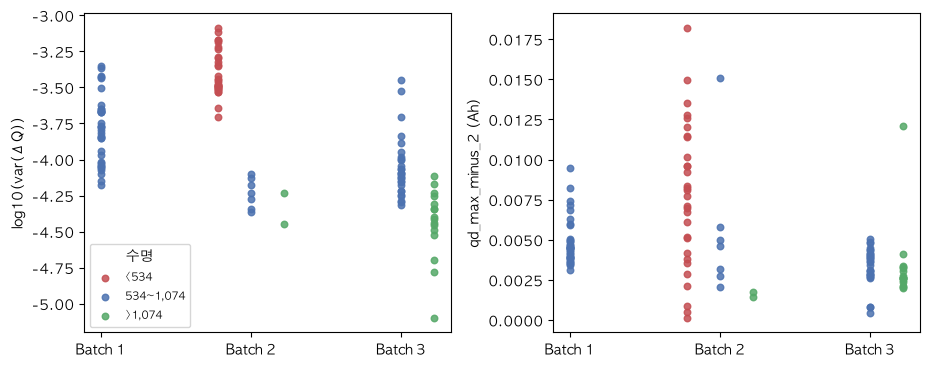

                log10_var  qd_max_minus_2
batch band                               
1     534~1074     -3.786           0.004
2     534~1074     -4.231           0.005
      <534         -3.455           0.008
      >1074        -4.340           0.002
3     534~1074     -4.097           0.004
      >1074        -4.403           0.003


In [4]:
bands = (
    ("<534", feat["cycle_life"] < 534, "#C44E52"),
    ("534~1,074", feat["cycle_life"].between(534, 1074), "#4C72B0"),
    (">1,074", feat["cycle_life"] > 1074, "#55A868"),
)
offsets = {"<534": -0.22, "534~1,074": 0.0, ">1,074": 0.22}
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8))
for ax, column, ylabel in (
    (axes[0], "log10_var", "log10(var(ΔQ))"),
    (axes[1], "qd_max_minus_2", "qd_max_minus_2 (Ah)"),
):
    for batch_id in (1, 2, 3):
        part = feat.loc[feat["batch"] == batch_id]
        for name, mask, color in bands:
            chosen = part.loc[mask]
            ax.scatter(
                np.full(len(chosen), batch_id) + offsets[name],
                chosen[column],
                s=22,
                color=color,
                alpha=0.85,
                label=name if batch_id == 1 else None,
            )
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Batch 1", "Batch 2", "Batch 3"])
    ax.set_ylabel(ylabel)
axes[0].legend(title="수명", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fe_feature_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print(feat.assign(band=np.where(feat["cycle_life"] < 534, "<534", np.where(feat["cycle_life"] > 1074, ">1074", "534~1074"))).groupby(["batch", "band"])[["log10_var", "qd_max_minus_2"]].median().round(3))


### 목적
두 메인 피처가 배치마다, 그리고 학습 수명 범위(534~1,074) 안팎에서 어떻게 다른지 본다. [설계 4장] [D29] [D30]

### 결과
Batch 1 36셀은 모두 학습 범위 안이고 log10(var(ΔQ)) 중앙은 −3.786이다. 같은 범위의 Batch 2(n=7)는 −4.231, Batch 3(n=28)는 −4.097이라 학습 배치의 분산이 더 크다. Batch 2에서 534 미만 30셀의 중앙은 −3.455로, 범위 안 7셀보다 분산이 크다. qd_max_minus_2 중앙은 534 미만에서 0.008Ah, 범위 안에서는 0.004~0.005Ah다.

### 해석
같은 수명 구간인데도 Batch 1의 ΔQ 분산이 Batch 2·3보다 크다. 이것은 설계서의 ΔQ 골 깊이 차이와 같은 방향이다. 짧은 Batch 2 셀은 분산이 더 커서, 범위 밖 예측이 피처 값 자체로도 학습 분포와 겹친다.

### 시사점 → 모델링
오차는 534 미만, 534~1,074, 1,074 초과의 세 구간으로 나눈다. Batch 2의 1,074 초과 2셀도 상한 구간에 넣는다. [D29] 같은 수명인데 학습 배치의 ΔQ가 더 깊으면 테스트 수명 과대예측을 먼저 의심한다. [D30]


## P9로 넘기는 것

- 모델 입력은 `log10_var`, `qd_max_minus_2` 두 개로 잠겼다. [D34] [D41]
- 학습 타깃은 `log10(cycle_life)`이고, MAPE는 10의 거듭제곱으로 되돌린 사이클 수로 계산한다. [D11]
- 사용 셀은 Batch 1 36, Batch 2 39, Batch 3 44다. 저장 파일은 `data/processed/features_batch{1,2,3}.csv`다. [D04]
- GroupKFold는 5폴드, 비교군은 `DecisionTreeRegressor(max_depth≤3)`와 `XGBRegressor(max_depth≤2)`다. 학습과 Batch 2 평가는 P9·P10에서 한다.
